In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
test_path = data_path + '/test'
results_path = project_path + '/results'

print("SERIAL 21 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Test folder exists:", os.path.exists(test_path))
print("Results folder exists:", os.path.exists(results_path))

Mounted at /content/drive
SERIAL 21 loaded successfully.
Project folder exists: True
Test folder exists: True
Results folder exists: True


#Load A-8 Telemetry and Autoencoder Result

In [2]:
channel = "A-8"

# Load A-8 test telemetry
test_A8 = np.load(test_path + "/" + channel + ".npy")
test_telemetry_A8 = test_A8[:, 0]

# Load Autoencoder evaluation result
autoencoder_result = pd.read_csv(
    results_path + "/autoencoder_evaluation_A8.csv"
)

print("Channel:", channel)
print("Test telemetry shape:", test_telemetry_A8.shape)

print("\nAutoencoder result:")
display(autoencoder_result)

Channel: A-8
Test telemetry shape: (8375,)

Autoencoder result:


,channel,method,threshold_method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Autoencoder,99th percentile of training reconstruction error,0.000422,0.320945,0.567262,0.40995,0.999781,0.432738,1,4568,1647,2159


In [4]:
train_path = data_path + '/train'

print("Train path:", train_path)
print("Train folder exists:", os.path.exists(train_path))

Train path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/data/raw/archive/data/data/train
Train folder exists: True


#Recalculate Reconstruction Errors

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load training telemetry
train_A8 = np.load(train_path + "/" + channel + ".npy")
train_telemetry_A8 = train_A8[:, 0]

# Convert to tensors
X_train_A8 = train_telemetry_A8.astype(np.float32).reshape(-1, 1)
X_test_A8 = test_telemetry_A8.astype(np.float32).reshape(-1, 1)

X_train_tensor = torch.tensor(X_train_A8)
X_test_tensor = torch.tensor(X_test_A8)

# Define the same Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


torch.manual_seed(42)

autoencoder = Autoencoder()

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

# Train the Autoencoder
for epoch in range(100):
    autoencoder.train()

    for (batch,) in train_loader:
        optimizer.zero_grad()

        reconstructed = autoencoder(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()


# Calculate reconstruction errors
autoencoder.eval()

with torch.no_grad():
    train_reconstructed = autoencoder(X_train_tensor)
    test_reconstructed = autoencoder(X_test_tensor)

train_errors = torch.mean(
    (X_train_tensor - train_reconstructed) ** 2,
    dim=1
).numpy()

test_errors = torch.mean(
    (X_test_tensor - test_reconstructed) ** 2,
    dim=1
).numpy()

threshold = np.percentile(train_errors, 99)

print("Training error mean:", train_errors.mean())
print("Test error mean:", test_errors.mean())
print("Threshold:", threshold)

Training error mean: 3.246022e-09
Test error mean: 0.11805009
Threshold: 1.6498891e-08


This run produced:

Training error: 3.25 × 10⁻⁹

Test error: 0.118

Threshold: 1.65 × 10⁻⁸

These are very different from SERIAL 20. That means the Autoencoder is highly sensitive to its learned weights/training path in this tiny 1D setup.

##Plot Reconstruction Error

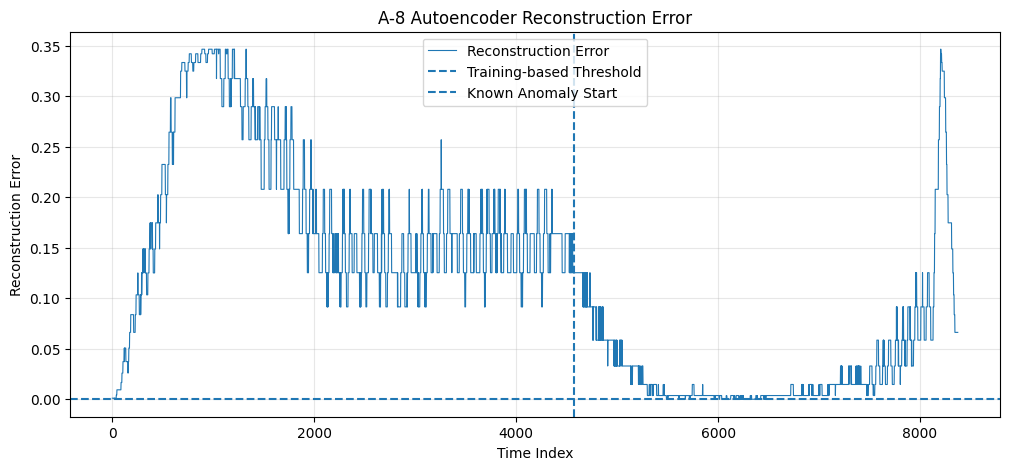

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_errors,
    linewidth=0.8,
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Training-based Threshold"
)

# Known A-8 anomaly starts at index 4569
plt.axvline(
    4569,
    linestyle="--",
    label="Known Anomaly Start"
)

plt.title("A-8 Autoencoder Reconstruction Error")
plt.xlabel("Time Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

A 1D Autoencoder trained on raw A-8 telemetry does not learn the temporal context needed to distinguish the normal and contextual-anomaly regimes.

##Compare Normal vs Anomaly Reconstruction Error

Let's make the comparison numerical rather than relying only on the graph.


In [7]:
anomaly_start = 4569
anomaly_end = 8374

normal_errors = test_errors[:anomaly_start]
anomaly_errors = test_errors[anomaly_start:anomaly_end + 1]

print("Normal region:")
print("Mean reconstruction error:", normal_errors.mean())
print("Median reconstruction error:", np.median(normal_errors))
print("Maximum reconstruction error:", normal_errors.max())

print("\nAnomaly region:")
print("Mean reconstruction error:", anomaly_errors.mean())
print("Median reconstruction error:", np.median(anomaly_errors))
print("Maximum reconstruction error:", anomaly_errors.max())

Normal region:
Mean reconstruction error: 0.18559794
Median reconstruction error: 0.16394126
Maximum reconstruction error: 0.34651998

Anomaly region:
Mean reconstruction error: 0.0369607
Median reconstruction error: 0.014604138
Maximum reconstruction error: 0.34651998


| Region  | Mean Error | Median Error |
| ------- | ---------: | -----------: |
| Normal  | **0.1856** |   **0.1639** |
| Anomaly | **0.0370** |   **0.0146** |

The surprising part is that the normal region has much higher reconstruction error than the labeled anomaly region.


The raw 1D Autoencoder fails to separate the normal and anomalous operating regimes of A-8 using reconstruction error.

##Calculate the Error Ratio

In [8]:
error_ratio = normal_errors.mean() / anomaly_errors.mean()

print("Normal-to-anomaly mean error ratio:", error_ratio)

Normal-to-anomaly mean error ratio: 5.0214944


A point-wise Autoencoder operating on a single raw telemetry value fails to capture the temporal context of the A-8 anomaly. This motivates sequence-based models such as an LSTM Autoencoder.

#github commit

In [9]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (31/31), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb
	modified:   notebooks/14_rolling_zscore.ipynb
	modified:   notebooks/15_compare_statistical_methods.ipynb
	modified:   notebooks/16_isolation_forest.ipynb
	modified:   notebooks/17_evaluate_isolation_forest.ipynb
	modified:   notebooks/18_one_class_svm.ipynb
	modified:   notebooks/19_compare_classical_methods.ipynb
	modified:   notebooks/20_autoencoder.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/21_analyze_autoencoder.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [10]:
!git add notebooks/21_analyze_autoencoder.ipynb

!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

!git commit -m "Complete SERIAL 21 Autoencoder analysis"

[main ae891ce] Complete SERIAL 21 Autoencoder analysis
 1 file changed, 1 insertion(+)
 create mode 100644 notebooks/21_analyze_autoencoder.ipynb


In [11]:
!git push origin main

Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 82.56 KiB | 10.32 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   d513891..ae891ce  main -> main
